# Volatility Model

In [80]:
from arch import arch_model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

In [81]:
# import data
df_train = pd.read_csv('../data/processed/SPY_Close_modeling_2.5y.csv')
df_train.tail()

,Date,close,log_return
618,2025-06-24,6092.18,0.011060
619,2025-06-25,6092.16,-0.000003
620,2025-06-26,6141.02,0.007988
621,2025-06-27,6173.07,0.005205
622,2025-06-30,6204.95,0.005151


In [82]:
df_train = df_train.sort_values("Date").set_index("Date")
df_train.head()

,close,log_return
Date,,
2023-01-04,3852.97,0.007511
2023-01-05,3808.10,-0.011714
2023-01-06,3895.08,0.022584
2023-01-09,3892.09,-0.000768
2023-01-10,3919.25,0.006954


In [83]:
df_train['log_return'].skew()

np.float64(0.386390035872416)

we can see in this time window, the skew is positive

### GARCH Modeling

In [84]:
# AR(0) mean model
y = df_train["log_return"].dropna()
mu = y.mean()
resid = y - mu

In [85]:
from arch import arch_model
import pandas as pd

# ------------------------------------------------------------
# Prepare residuals (already demeaned)
# ------------------------------------------------------------
resid_pct = 100 * resid

models = []

# ------------------------------------------------------------
# Define model configurations
# ------------------------------------------------------------
model_specs = [
    ("GARCH(1,1)-t", dict(vol="GARCH", p=1, q=1, dist="t")),
    ("EGARCH(1,1)-t", dict(vol="EGARCH", p=1, o=1, q=1, dist="t")),
    ("GJR(1,1)-t", dict(vol="GARCH", p=1, o=1, q=1, dist="t")),
    ("FIGARCH(1,d,1)-t",  dict(vol="FIGARCH", p=1, q=1, dist="t")),
    ("GARCH(1,1)-skewt", dict(vol="GARCH", p=1, q=1, dist="skewt")),
    ("EGARCH(1,1)-skewt", dict(vol="EGARCH", p=1, o=1, q=1, dist="skewt")),
    ("GJR(1,1)-skewt", dict(vol="GARCH", p=1, o=1, q=1, dist="skewt")),
    ("FIGARCH(1,d,1)-skewt", dict(vol="FIGARCH", p=1, q=1, dist="skewt"))
]

# ------------------------------------------------------------
# Fit all models and collect information criteria
# ------------------------------------------------------------
for name, spec in model_specs:
    try:
        am = arch_model(
            resid_pct,
            mean="Zero",
            vol=spec["vol"],
            p=spec.get("p", 1),
            o=spec.get("o", 0),
            q=spec.get("q", 1),
            dist=spec["dist"]
        )
        
        fit = am.fit(disp="off")
        
        models.append({
            "Model": name,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "LogLik": fit.loglikelihood
        })
        
    except:
        continue

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------
comparison_df = pd.DataFrame(models).sort_values("BIC", ).reset_index(drop=True)

print("\n" + "="*60)
print("Model Comparison")
print("="*60)
print(comparison_df)



Model Comparison
                  Model          AIC          BIC      LogLik
0     EGARCH(1,1)-skewt  1542.800551  1569.407830 -765.400275
1         EGARCH(1,1)-t  1550.033202  1572.205934 -770.016601
2        GJR(1,1)-skewt  1550.779384  1577.386663 -769.389692
3            GJR(1,1)-t  1557.797586  1579.970319 -773.898793
4          GARCH(1,1)-t  1586.664827  1604.403013 -789.332414
5      GARCH(1,1)-skewt  1582.644911  1604.817644 -786.322456
6  FIGARCH(1,d,1)-skewt  1587.099967  1613.707246 -787.549983
7      FIGARCH(1,d,1)-t  1591.861834  1614.034566 -790.930917


### Models Comparison

##### for skew-t distribution 
1. **eta:**  Controls tail thickness of the skewed Student’s t distribution, capturing the degree of fat-tail risk in returns.
2. **λ:** : Controls the skewness of the distribution, indicating whether extreme returns are more likely on the left (negative) or right (positive) side.

##### GARCH

In [86]:
garch11_skewt = arch_model(
    resid_pct,
    mean="Zero",
    vol="GARCH",
    p=1, q=1, 
    dist="skewt"
).fit(disp="off")

print(garch11_skewt.summary())

                             Zero Mean - GARCH Model Results                             
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                            Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                 GARCH   Log-Likelihood:               -786.322
Distribution:      Standardized Skew Student's t   AIC:                           1582.64
Method:                       Maximum Likelihood   BIC:                           1604.82
                                                   No. Observations:                  623
Date:                           Mon, Mar 30 2026   Df Residuals:                      623
Time:                                   23:18:44   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------

In [87]:
garch11_t = arch_model(
    resid_pct,
    mean="Zero",
    vol="GARCH",
    p=1, q=1, 
    dist="t"
).fit(disp="off")

print(garch11_t.summary())

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -789.332
Distribution:      Standardized Student's t   AIC:                           1586.66
Method:                  Maximum Likelihood   BIC:                           1604.40
                                              No. Observations:                  623
Date:                      Mon, Mar 30 2026   Df Residuals:                      623
Time:                              23:18:44   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

**The GARCH(1,1) with Skewed Student's t distribution is the superior model** 

- **Optimal Information Criteria:** TThe Skewed Student's t model achieves a lower AIC (1582.64) compared to the standard t-distribution (1586.66), indicating a more precise fit to the empirical data.

- **Significant Asymmetry::** The skewness parameter (lambda) is statistically significant (p = 0.011), confirming that SPY returns exhibit non-symmetric behavior that a standard t-distribution fails to capture.

- **Reliable Persistence Estimates:** All core volatility parameters (alpha and beta) remain highly significant (p < 0.01), ensuring stable estimates of volatility clustering.

##### GJR-GARCH

In [88]:
gjr_garch11_skewt = arch_model(
    resid_pct,
    mean="Zero",
    vol="GARCH",
    p=1, o=1, q=1,
    dist="skewt"
).fit(disp="off")

print(gjr_garch11_skewt.summary())

                           Zero Mean - GJR-GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                            Zero Mean   Adj. R-squared:                  0.002
Vol Model:                             GJR-GARCH   Log-Likelihood:               -769.390
Distribution:      Standardized Skew Student's t   AIC:                           1550.78
Method:                       Maximum Likelihood   BIC:                           1577.39
                                                   No. Observations:                  623
Date:                           Mon, Mar 30 2026   Df Residuals:                      623
Time:                                   23:18:44   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
--------------------------------------------

In [89]:
gjr_garch11_t = arch_model(
    resid_pct,
    mean="Zero",
    vol="GARCH",
    p=1, o=1, q=1,
    dist="t"
).fit(disp="off")

print(gjr_garch11_t.summary())

                        Zero Mean - GJR-GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                        GJR-GARCH   Log-Likelihood:               -773.899
Distribution:      Standardized Student's t   AIC:                           1557.80
Method:                  Maximum Likelihood   BIC:                           1579.97
                                              No. Observations:                  623
Date:                      Mon, Mar 30 2026   Df Residuals:                      623
Time:                              23:18:44   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega  

**The GJR-GARCH with Skewed Student's t distribution is the superior model** 

- **Optimal Information Criteria:** This model yields the lowest AIC (1550.78) across all tested configurations, indicating the best balance between model complexity and data fit.

- **Superior Log-Likelihood:** It achieves the highest Log-Likelihood (-769.39), demonstrating that the Skewed Student's t distribution maps the empirical S&P 500 returns more accurately than the standard t-distribution.

##### EGARCH

In [90]:
egarch11_t = arch_model(
    resid_pct,
    mean="Zero",
    vol="EGARCH",
    p=1, o=1, q=1,
    dist="t"
).fit(disp="off")

print(egarch11_t.summary())

                          Zero Mean - EGARCH Model Results                          
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                           EGARCH   Log-Likelihood:               -770.017
Distribution:      Standardized Student's t   AIC:                           1550.03
Method:                  Maximum Likelihood   BIC:                           1572.21
                                              No. Observations:                  623
Date:                      Mon, Mar 30 2026   Df Residuals:                      623
Time:                              23:18:44   Df Model:                            0
                               Volatility Model                               
                 coef    std err          t      P>|t|        95.0% Conf. Int.
-----------------------------------------------------------------------------

In [91]:
egarch11_skewt = arch_model(
    resid_pct,
    mean="Zero",
    vol="EGARCH",
    p=1,o=1, q=1,
    dist="skewt"
).fit(disp="off")

print(egarch11_skewt.summary())

                             Zero Mean - EGARCH Model Results                            
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                            Zero Mean   Adj. R-squared:                  0.002
Vol Model:                                EGARCH   Log-Likelihood:               -765.400
Distribution:      Standardized Skew Student's t   AIC:                           1542.80
Method:                       Maximum Likelihood   BIC:                           1569.41
                                                   No. Observations:                  623
Date:                           Mon, Mar 30 2026   Df Residuals:                      623
Time:                                   23:18:44   Df Model:                            0
                               Volatility Model                               
                 coef    std err          t      P>|t|        95.0% Conf. Int.
--------------------------------

**The EGARCH(1,1) with Skewed Student's t distribution is the superior model** 

- **Statistical Evidence of Skewness:** All key parameters—including the leverage effect (gamma) and the skewness parameter (lambda)—are highly significant (p < 0.01), ensuring the model is not over-fitted.

- **Superior Fit Metrics:** This model achieves a lower **AIC to 1542.90** (compared to 1550.03 for the standard t), proving that accounting for skewness provides a more precise representation of the data.

- **Capturing Distributional Bias:** The significant lambda (-0.1691) confirms that the residuals are negatively skewed, a crucial detail for risk management that the standard t-distribution misses.

##### FIGARCH

In [92]:
figarch11_t = arch_model(
    resid_pct,
    mean="Zero",
    vol="FIGARCH",
    p=1, q=1,
    dist="t"
).fit(disp="off")

print(figarch11_t.summary())

                         Zero Mean - FIGARCH Model Results                          
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                          FIGARCH   Log-Likelihood:               -790.931
Distribution:      Standardized Student's t   AIC:                           1591.86
Method:                  Maximum Likelihood   BIC:                           1614.03
                                              No. Observations:                  623
Date:                      Mon, Mar 30 2026   Df Residuals:                      623
Time:                              23:18:44   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

In [93]:
figarch11_skewt = arch_model(
    resid_pct,
    mean="Zero",
    vol="FIGARCH",
    p=1, q=1,
    dist="skewt"
).fit(disp="off")

print(figarch11_skewt.summary())

                            Zero Mean - FIGARCH Model Results                            
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                            Zero Mean   Adj. R-squared:                  0.002
Vol Model:                               FIGARCH   Log-Likelihood:               -787.550
Distribution:      Standardized Skew Student's t   AIC:                           1587.10
Method:                       Maximum Likelihood   BIC:                           1613.71
                                                   No. Observations:                  623
Date:                           Mon, Mar 30 2026   Df Residuals:                      623
Time:                                   23:18:44   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------

**The FIGARCH(1,d,1) with Skewed Student’s t distribution provides a slightly better fit than the standard Student’s t specification**- 
- **Improved Model Fit:** The skewed-t version achieves a lower AIC (1587.10) compared with the standard t-distribution (1591.86), indicating that allowing for skewness slightly improves the model’s ability to capture the data dynamics.
- **Evidence of Long-Memory Volatility:** The fractional integration parameter d is estimated around 0.57–0.61, suggesting persistent long-memory behavior in volatility, although its statistical significance is relatively weak across specifications.
- **Capturing Asymmetric Distribution:** The skewness parameter (λ ≈ −0.14) is statistically significant, indicating that the return distribution is negatively skewed, which the symmetric t-distribution cannot capture effectively.

#### Conclusion: 
- Overall GARCH-Models with skew-t distribution performanced better than t-distribution. for later prediction and residual test, we will only use GARCH-Models with skew-t distribution

In [94]:
import pandas as pd
from statsmodels.stats.diagnostic import het_arch

# ------------------------------------------------------------
# Put models into a dictionary
# ------------------------------------------------------------
models = {
    "GARCH(1,1)-skewt": garch11_skewt,
    "GJR(1,1)-skewt": gjr_garch11_skewt,
    "EGARCH(1,1)-skewt": egarch11_skewt,
    "FIGARCH(1,d,1)-skewt": figarch11_skewt
}

results = []

# ------------------------------------------------------------
# Run ARCH-LM test for each model
# ------------------------------------------------------------
for name, model in models.items():
    
    std_resid = model.std_resid.dropna()
    
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(std_resid, nlags=10)
    
    results.append({
        "Model": name,
        "LM Statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F Statistic": f_stat,
        "F p-value": f_pvalue
    })

# ------------------------------------------------------------
# Create DataFrame table
# ------------------------------------------------------------
arch_lm_table = pd.DataFrame(results)

# sort by LM p-value (optional)
arch_lm_table = arch_lm_table.sort_values("LM p-value", ascending=False)

print("\n" + "="*70)
print("ARCH-LM Test Results")
print("="*70)

print(arch_lm_table.round(4))


ARCH-LM Test Results
                  Model  LM Statistic  LM p-value  F Statistic  F p-value
1        GJR(1,1)-skewt        8.5353      0.5767       0.8500     0.5804
2     EGARCH(1,1)-skewt       11.9468      0.2886       1.1966     0.2900
3  FIGARCH(1,d,1)-skewt       16.4836      0.0866       1.6635     0.0857
0      GARCH(1,1)-skewt       26.2256      0.0034       2.6906     0.0031


**ARCH-LM Test Interpretation** 

The ARCH-LM test checks whether remaining ARCH effects still exist in model residuals.
- Null hypothesis (H₀): No ARCH effects remain (model is adequate)
- If p-value < 0.05 → ARCH effects remain → model is inadequate
- If p-value > 0.05 → no ARCH effects → model captures volatility well

Result: 
1. GARCH(1,1) – Skew-t: 
    - LM p-value: 0.0034 -> Reject H₀ → ARCH effects remain
2. GJR-GARCH(1,1) – Skew-t: 
    - LM p-value: 0.5767 -> Fail to reject H₀ → no remaining ARCH effects
3. EGARCH(1,1) – Skew-t: 
    - LM p-value: 0.2886 -> Fail to reject H₀ → no remaining ARCH effects
4. FIGARCH(1,d,1) – Skew-t: 
    - LM p-value: 0.0866 -> Fail to reject H₀ → no remaining ARCH effects

In [95]:
# Ljung-Box test on squared standardized residuals
from statsmodels.stats.diagnostic import acorr_ljungbox

std_garch = garch11_skewt.std_resid.dropna()
std_gjr = gjr_garch11_skewt.std_resid.dropna()
std_egarch = egarch11_skewt.std_resid.dropna()
std_figarch = figarch11_skewt.std_resid.dropna()

# --- Diagnostics for GARCH(1,1)-skewt ---
lb_garch_sq = acorr_ljungbox(std_garch**2, lags=[10, 20], return_df=True)

print("\n" + "="*60)
print("GARCH(1,1)-skewt: Ljung-Box on squared standardized residuals")
print("="*60)
print(lb_garch_sq)

# --- Diagnostics for GJR(1,1)-skewt ---  
lb_gjr_sq = acorr_ljungbox(std_gjr**2, lags=[10, 20], return_df=True)

print("\n" + "="*60)
print("GJR(1,1)-skewt: Ljung-Box on squared standardized residuals")
print("="*60)
print(lb_gjr_sq)

# --- Diagnostics for EGARCH(1,1)-skewt ---  
lb_egarch_sq = acorr_ljungbox(std_egarch**2, lags=[10, 20], return_df=True)

print("\n" + "="*60)
print("EGARCH(1,1)-skewt: Ljung-Box on squared standardized residuals")
print("="*60)
print(lb_egarch_sq)

# --- Diagnostics for FIGARCH(1,1)-skewt ---  
lb_figarch_sq = acorr_ljungbox(std_figarch**2, lags=[10, 20], return_df=True)

print("\n" + "="*60)
print("FIGARCH(1,d,1)-skewt: Ljung-Box on squared standardized residuals")
print("="*60)
print(lb_figarch_sq)


GARCH(1,1)-skewt: Ljung-Box on squared standardized residuals
      lb_stat  lb_pvalue
10  27.885004   0.001883
20  31.987317   0.043434

GJR(1,1)-skewt: Ljung-Box on squared standardized residuals
      lb_stat  lb_pvalue
10   9.536517   0.482052
20  14.537845   0.802214

EGARCH(1,1)-skewt: Ljung-Box on squared standardized residuals
      lb_stat  lb_pvalue
10  13.045715   0.221127
20  16.324374   0.696308

FIGARCH(1,d,1)-skewt: Ljung-Box on squared standardized residuals
      lb_stat  lb_pvalue
10  17.032536   0.073647
20  21.006105   0.396773


**Ljung–Box Test on Squared Standardized Residuals**

This test checks whether remaining autocorrelation in volatility exists after model estimation.
- H₀: No autocorrelation remains (model captures volatility dynamics)
- p-value < 0.05 → remaining structure exists → model inadequate
- p-value > 0.05 → no remaining structure → model adequate

Result: 
1. GARCH(1,1) – Skew-t: 
    - Lag 10 p-value: 0.0019 -> Reject H₀ → significant autocorrelation remains
    - Lag 20 p-value: 0.0434 -> Reject H₀ → significant autocorrelation remains
2. GJR-GARCH(1,1) – Skew-t: 
    - Lag 10 p-value: 0.4821 -> Fail to reject H₀ → no remaining autocorrelation
    - Lag 20 p-value: 0.8022 -> Fail to reject H₀ → no remaining autocorrelation
3. EGARCH(1,1) – Skew-t: 
    - Lag 10 p-value: 0.2211 -> Fail to reject H₀ → no remaining autocorrelation
    - Lag 20 p-value: 0.6963 -> Fail to reject H₀ → no remaining autocorrelation
4. FIGARCH(1,d,1) – Skew-t: 
    - Lag 10 p-value: 0.07365 -> Fail to reject H₀ → no remaining autocorrelation
    - Lag 20 p-value: 0.3967 -> Fail to reject H₀ → no remaining autocorrelation

In [96]:
# resid: demeaned returns (AR(0) residuals)
lambda_ = 0.94
train_ret = df_train["log_return"].dropna()

train_returns_pct = 100 * train_ret

# Initial variance from training sample
sigma2 = np.var(train_returns_pct)

## Get BIC for EWMA train data
ewma_train_var = []
sigma2 = np.var(train_returns_pct)

for r in train_returns_pct:
    sigma2 = lambda_ * sigma2 + (1 - lambda_) * r**2
    ewma_train_var.append(sigma2)

ewma_train_var = np.array(ewma_train_var)

n = len(train_returns_pct)
k = 1  # Only lambda parameter
loglik_ewma = -0.5 * np.sum(np.log(ewma_train_var) + train_returns_pct**2 / ewma_train_var)
bic_ewma = -2 * loglik_ewma + k * np.log(n)
print("\nEWMA Model BIC:", bic_ewma)


EWMA Model BIC: 401.4710342885369


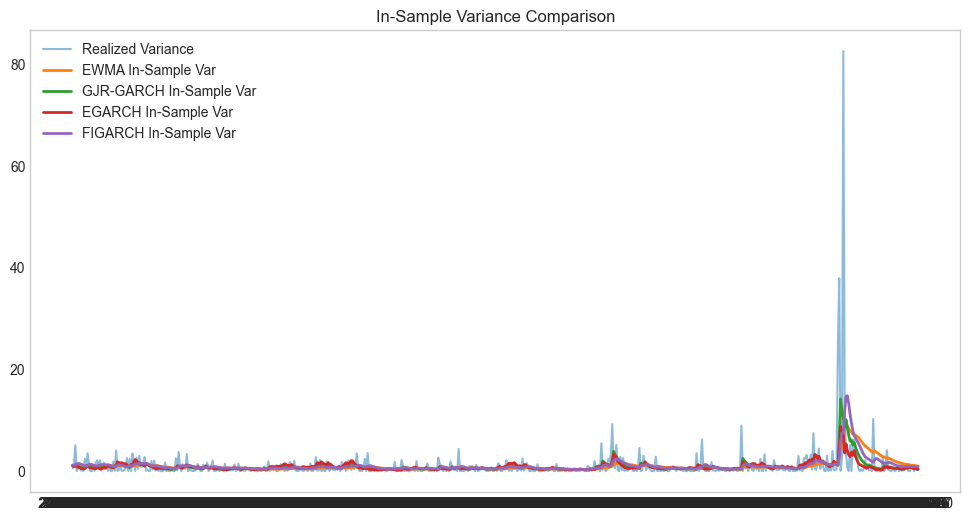

In [104]:
#   in-sample variance comparison
gjr_in_sample_variance = gjr_garch11_skewt.conditional_volatility**2
egarch_in_sample_variance = egarch11_skewt.conditional_volatility**2
figarch_in_sample_variance = figarch11_skewt.conditional_volatility**2
realized_variance = train_returns_pct.values**2

lambda_ = 0.94
returns = train_returns_pct.values
ewma_var_in = np.zeros(len(returns))
ewma_var_in[0] = np.var(returns)

for t in range(1, len(returns)):
    ewma_var_in[t] = (
        lambda_ * ewma_var_in[t-1] +
        (1 - lambda_) * returns[t-1]**2
    )

plt.figure(figsize=(12, 6))

plt.plot(realized_variance, label="Realized Variance", alpha=0.5)
plt.plot(ewma_var_in, label="EWMA In-Sample Var", linewidth=2)
plt.plot(gjr_in_sample_variance, label="GJR-GARCH In-Sample Var", linewidth=2)
plt.plot(egarch_in_sample_variance, label="EGARCH In-Sample Var", linewidth=2)
plt.plot(figarch_in_sample_variance, label="FIGARCH In-Sample Var", linewidth=2)
plt.grid(False)

plt.title("In-Sample Variance Comparison")
plt.legend()
plt.show()

### Volatility Model Forecasting

In [98]:
df_test = pd.read_csv('../data/processed/SPY_Close_forecast_0.5y.csv')
df_test = df_test.sort_values("Date").set_index("Date")
test_returns_pct = 100 * df_test["log_return"].values
df_test.head()

,close,log_return
Date,,
2025-07-01,6198.01,-0.001119
2025-07-02,6227.42,0.004734
2025-07-03,6279.35,0.008304
2025-07-07,6229.98,-0.007893
2025-07-08,6225.52,-0.000716


In [99]:
df_vol_test = pd.read_csv('../data/processed/SPX_Intraday_Vol.csv')
df_vol_test.head()


,trade_date,intraday_avg_vol
0,2025-07-07,0.001718
1,2025-07-08,0.000906
2,2025-07-09,0.001095
3,2025-07-10,0.000713
4,2025-07-11,0.000620


In [100]:
df_test.index = pd.to_datetime(df_test.index)

df_vol = df_vol_test.copy()
df_vol['trade_date'] = pd.to_datetime(df_vol['trade_date'])
df_vol = df_vol.set_index('trade_date')

# Use intraday average volume as a proxy for daily variance
N = 13
df_vol['True_Variance'] = (df_vol['intraday_avg_vol'] * np.sqrt(N) * 100) ** 2

# Keep only the relevant columns and align with test data
aligned_data = df_vol[['True_Variance']].join(df_test['log_return'], how='inner')

# Align returns with true variance
aligned_returns_pct = aligned_data['log_return'] * 100

In [101]:
gjr_forecasts = []
egarch_forecasts = []
figarch_forecasts = []
ewma_forecasts = []

# historical returns for rolling forecast
history = list(train_returns_pct.values)

# EWMA parameters
lambda_ewma = 0.94
current_ewma_var = np.var(history)

for i in range(len(aligned_returns_pct)):
   
    # GJR-GARCH
    model_gjr = arch_model(history, p=1, o=1, q=1, vol='GARCH', dist='skewt', mean='Constant')
    res_gjr = model_gjr.fit(disp='off')
    pred_gjr = res_gjr.forecast(horizon=1)
    gjr_forecasts.append(pred_gjr.variance.iloc[-1, 0])

    # EGARCH
    model_egarch = arch_model(history, p=1, o=1, q=1, vol='EGARCH', dist='skewt', mean='Constant')
    res_egarch = model_egarch.fit(disp='off')
    pred_egarch = res_egarch.forecast(horizon=1)
    egarch_forecasts.append(pred_egarch.variance.iloc[-1, 0])

    # FIGARCH
    model_figarch = arch_model(history, p=1, o=1, q=1, vol='FIGARCH', dist='skewt', mean='Constant')
    res_figarch = model_figarch.fit(disp='off')
    pred_figarch = res_figarch.forecast(horizon=1)
    figarch_forecasts.append(pred_figarch.variance.iloc[-1, 0])

    #EWMA
    ewma_forecasts.append(current_ewma_var)
    today_return = aligned_returns_pct.iloc[i]
    current_ewma_var = lambda_ewma * current_ewma_var + (1 - lambda_ewma) * (today_return ** 2)

    # Renew history with actual return
    history.append(today_return)

# Aligned_data
aligned_data['GJR_Forecast'] = gjr_forecasts
aligned_data['EGARCH_Forecast'] = egarch_forecasts
aligned_data['FIGARCH_Forecast'] = figarch_forecasts
aligned_data['EWMA_Forecast'] = ewma_forecasts

In [102]:
from sklearn.metrics import mean_squared_error

def calculate_qlike(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)

y_true = aligned_data['True_Variance']

# --- calculate MSE ---
mse_gjr = mean_squared_error(y_true, aligned_data['GJR_Forecast'])
mse_egarch = mean_squared_error(y_true, aligned_data['EGARCH_Forecast'])
mse_figarch = mean_squared_error(y_true, aligned_data['FIGARCH_Forecast'])
mse_ewma = mean_squared_error(y_true, aligned_data['EWMA_Forecast'])

# --- calculate QLIKE ---
qlike_gjr = calculate_qlike(y_true, aligned_data['GJR_Forecast'])
qlike_egarch = calculate_qlike(y_true, aligned_data['EGARCH_Forecast'])
qlike_figarch = calculate_qlike(y_true, aligned_data['FIGARCH_Forecast'])
qlike_ewma = calculate_qlike(y_true, aligned_data['EWMA_Forecast'])

# --- print ---
print("\n=== Final Results (Intraday Only) ===")
print(f"{'Model':<12} | {'MSE':<10} | {'QLIKE':<10}")
print("-" * 35)
print(f"GJR-GARCH    | {mse_gjr:.6f} | {qlike_gjr:.6f}")
print(f"EGARCH       | {mse_egarch:.6f} | {qlike_egarch:.6f}")
print(f"FIGARCH      | {mse_figarch:.6f} | {qlike_figarch:.6f}")
print(f"EWMA         | {mse_ewma:.6f} | {qlike_ewma:.6f}")


=== Final Results (Intraday Only) ===
Model        | MSE        | QLIKE     
-----------------------------------
GJR-GARCH    | 0.282972 | 0.692995
EGARCH       | 0.244247 | 0.702517
FIGARCH      | 0.305676 | 0.775561
EWMA         | 0.238234 | 0.727231


## Conclusion: 
- EWMA outperforms GARCH-type models in out-of-sample volatility forecasting.
- Simpler models can outperform complex ones when market volatility shifts quickly.
- GARCH-family models may fit in-sample dynamics better but can overfit.

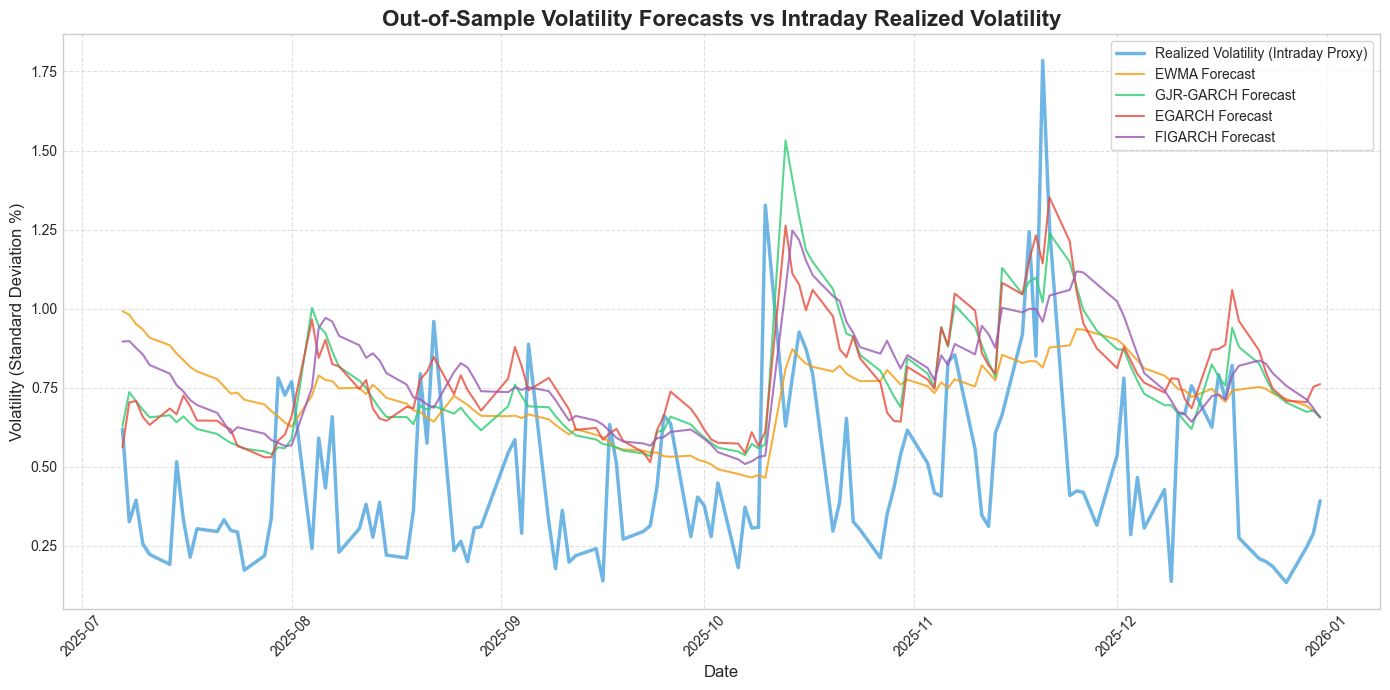

In [103]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(aligned_data.index, np.sqrt(aligned_data['True_Variance']), 
         label='Realized Volatility (Intraday Proxy)', color='#3498db', alpha=0.7, linewidth=2.5)

plt.plot(aligned_data.index, np.sqrt(aligned_data['EWMA_Forecast']), 
         label='EWMA Forecast', color='#f39c12', alpha=0.8, linewidth=1.5)

plt.plot(aligned_data.index, np.sqrt(aligned_data['GJR_Forecast']), 
         label='GJR-GARCH Forecast', color='#2ecc71', alpha=0.8, linewidth=1.5)

plt.plot(aligned_data.index, np.sqrt(aligned_data['EGARCH_Forecast']), 
         label='EGARCH Forecast', color='#e74c3c', alpha=0.8, linewidth=1.5)

plt.plot(aligned_data.index, np.sqrt(aligned_data['FIGARCH_Forecast']), 
         label='FIGARCH Forecast', color='#9b59b6', alpha=0.8, linewidth=1.5)

plt.title('Out-of-Sample Volatility Forecasts vs Intraday Realized Volatility', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility (Standard Deviation %)', fontsize=12)

plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()